<a href="https://colab.research.google.com/github/VildanaRazumova/thesis-demand-forecasting/blob/main/thesis_notebook_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand-Based Dynamic Pricing Models for Travel Markets

---

# The following Project information



**Client:** A leading B2B tour operator in Kazakhstan and Central Asia, cooperating with 5,000+ travel agencies across destinations including Vietnam, Thailand, Egypt, Turkey, UAE and the Maldives

**Problem statement & Importance:**
Tour operators in B2B travel markets must commit to flight and hotel inventory 6-8 months in advance, without knowing the actual demand. Traditional demand estimation methods rely on historical bookings and expert judgment, which becomes insufficient when market conditions shift due to competitor pricing, seasonal search trends, and external events. This uncertainty leads to either unsold seats or missed revenue opportunities. A critical business challenge is not only whether demand can be predicted accurately, but also how early in the booking window a reliable prediction can be made, giving the operator enough time to act.

**Goal:**
This study focuses on the Kazakhstan - Vietnam route as a pilot, as Vietnam is the operator's most popular destination and each route has unique demand patterns, seasonality, and external signals.


**Methodology:**
The methodology is designed to be scalable and applicable to other destinations in subsequent research.

The primary objective is to develop and evaluate machine learning models that predict flight load factor at multiple booking windows (D-90, D-60, D-30, D-7), using a multivariate feature set constructed from internal booking signals at each point in time.

The study additionally assesses whether external market signals improve prediction accuracy beyond internal booking data alone, and identifies the earliest booking window at which reliable load factor predictions can be made to support dynamic pricing decisions.

---

Load Factor = Seats Sold / Total Seats x 100%

---

**Business Benefits:**
1. Identifies the earliest reliable prediction window
2. Reduces financial risk from unsold charter seats
3. Provides a data-driven foundation for dynamic price decisions
4. Competitive advantage over operators using rule-based pricing only

**Relevant data collected from:**

Historical Internal signals (2024-2026):
-  booking claims: lead time, pax, hotel & flight costs
-  flight capacity: seats sold, empty seats, load factor per window

External signals at specific points in the past:
- Google Trends API: search interest per destination
- Google News API: news per country
- Public holiday calendars: event & holiday flags

**Approach:**

A time-series approach is used throughout this project. Features are constructed at each booking window using only information available at that point in time, preventing data leakage and ensuring realistic future deployment.

**Core Task: Load Factor Prediction at multiple booking windows**

| Window | Days Before Departure | Business Meaning |
|--------|----------------------|------------------|
| D-90 | 90 days | Early signal: low booking activity |
| D-60 | 60 days | Search trends become informative |
| D-30 | 30 days | Majority of bookings visible |
| D-7  | 7 days  | Final occupancy picture |

Two experiments are conducted:
- Baseline model: internal features only (Linear Regression)
- Extended model: internal + external signals (Random Forest, XGBoost, LightGBM)

# Project Pipeline

This project will be approached through the following steps:

1. **Importing the Libraries**: loading all required Python packages
   for data analysis, visualisation and machine learning

2. **Importing the Data**: loading claims and flight load history
   datasets from Google Drive

3. **Claims Data Overview & Flights Data Overview**: understanding the structure, shape, date ranges
   and column descriptions of both datasets

4. **Exploratory Data Analysis (EDA)**: analysing demand patterns,
   seasonality, lead time distribution and booking window behaviour
   for Vietnam routes

5. **Joint Analysis**: Linking claims to flights via FreightID + BlockDate to reconstruct booking curve.

6. **Data Preprocessing**: filtering irrelevant routes and bookings,
  handling data types,dropping irrelevant columns, joining claims with flights

7. **Feature Engineering**: constructing internal features (booking
   pace, lead time) and external signals
   (price ratio, search trends, holidays) at each booking window
   (D-90, D-60, D-30, D-7)

8. **Model Building**: training baseline models (internal features
   only) and extended models (internal + external features) using
   Linear Regression, Random Forest, XGBoost and LightGBM

9. **Model Evaluation**: comparing model performance across booking
   windows using MAPE, MAE, RMSE and R2

10. **Conclusion** identifying the earliest booking window at which the model achieves reliable load factor predictions, quantifying the improvement from adding external signals, and discussing implications for dynamic pricing decisions in B2B charter tourism.

# 1. Importing the Libraries

In [19]:
# Import Libraries
from google.colab import drive

# Data libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from pandas.plotting import autocorrelation_plot

# 2. Import the Data

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


### Load Claims

In [3]:
df_claims = pd.read_csv(
    '/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/dp_claims_features.csv'
)

In [4]:
df_claims.head(3)

,snapshot_date,snapshot_ts_utc,ClaimID,TourID,StatusID,StatusName,IsCancelled,ClaimCreatedDT_UTC,raw_event_time_utc,DepartureDT,...,FlightPartnerID_Fwd,FlightPartner_Fwd,FlightPartnerID_Bck,FlightPartner_Bck,FlightCost_Fwd,FlightCost_Bck,RevisionAmount_Fwd,RevisionAmount_Bck,CurrencyClaimID,CurrencyAlias
0,2026-03-17,2026-03-17 16:54:25,8211917,23966,1,Paid,0,2024-05-21 11:00:00,2024-05-21 11:00:00,2024-08-01,...,157575,SCAT,157575,SCAT,944.16,704.16,120.0,0.0,2,USD
1,2026-03-17,2026-03-17 16:54:25,8456807,23966,1,Paid,0,2024-07-19 10:52:00,2024-07-19 10:52:00,2024-08-01,...,157575,SCAT,157575,SCAT,974.16,704.16,135.0,0.0,2,USD
2,2026-03-17,2026-03-17 16:54:25,8433696,23966,1,Paid,0,2024-07-14 14:59:00,2024-07-14 14:59:00,2024-08-03,...,194333,VietJet,194333,VietJet,1726.52,776.52,475.0,0.0,2,USD


### Load Flights

In [20]:
df_flights = pd.read_csv(
    '/content/drive/MyDrive/Thesis_RazumovaV_2026/thesis_data/dp_flight_load_history.csv',
    on_bad_lines='skip'
)

In [6]:
df_flights.head(3)

,snapshot_date,snapshot_ts_utc,FreightID,FlightName,BlockDate,IsReturn,AirlinePartnerID,AirlineName,FlightClassID,ClassAlias,...,IsOnRequest,Seats_gross,Sold_gross,Empty,Seats_net,Sold_net,BlockRecords,TotalDaysInSale,ResourceCount,last_stamp
0,2026-03-17,2026-03-17 16:54:53,10670,VSV5208,2024-01-01,1,157575,SCAT (),2,Y,...,0,183,2,181,183,2,1,157,1,46013423911
1,2026-03-17,2026-03-17 16:54:53,11538,VJ61,2024-01-01,1,194333,VietJet Air,2,Y,...,0,30,0,30,30,0,1,137,1,46010971579
2,2026-03-17,2026-03-17 16:54:53,12523,VSV5319,2024-01-01,1,157575,SCAT (),2,Y,...,0,30,6,24,30,6,1,52,1,46012591950


# 3.1. Claims Data Overview

1. General Overview
2. Data types
3. Check duplicates
4. Booking Status Distribution
5. Basic Statistics

In [21]:
# 1. General Overview
print(f'Rows: {df_claims.shape[0]:,}')
print(f'Columns: {df_claims.shape[1]}')
print(f'Booking date: {df_claims["ClaimCreatedDT_UTC"].min()} - {df_claims["ClaimCreatedDT_UTC"].max()}')
print(f'Departure: {df_claims["DepartureDT"].min()} - {df_claims["DepartureDT"].max()}')
print(f'Destination: {df_claims["CountryName"].unique()}')
print(f'Missing: {df_claims.isnull().sum().sum()}')

Rows: 37,674
Columns: 64
Booking date: 2023-09-05 11:57:00 - 2026-03-04 08:15:00
Departure: 2024-01-01 - 2026-03-05
Destination: ['Vietnam']
Missing: 145


In [22]:
# Misssing Values in details
df_claims.isnull().sum()[df_claims.isnull().sum() > 0]

,0
HotelName,29
MealName,29
RoomTypeName,29
AccommodationName,29
HotelRegion,29


In [23]:
df_claims[df_claims['HotelName'].isnull()]['TourTypeName'].value_counts()

,count
TourTypeName,
Dynamic package,24
Beach Tours,5


In [24]:
# Check booked AFTER departure
print(f"Negative lead times: {(df_claims['LeadTimeDays'] < 0).sum()}")
print(f"Zero lead times: {(df_claims['LeadTimeDays'] == 0).sum()}")

Negative lead times: 0
Zero lead times: 27


In [11]:
# 2. Data types
df_claims.dtypes

,0
snapshot_date,object
snapshot_ts_utc,object
ClaimID,int64
TourID,int64
StatusID,int64
...,...
FlightCost_Bck,float64
RevisionAmount_Fwd,float64
RevisionAmount_Bck,float64
CurrencyClaimID,int64


In [25]:
# 3. Check duplicates
print(f'Duplicate ClaimIDs:  {df_claims["ClaimID"].duplicated().sum()}')
print(f'Duplicate rows:      {df_claims.duplicated().sum()}')

Duplicate ClaimIDs:  0
Duplicate rows:      0


In [26]:
# 4. Booking Status Distribution
print(df_claims['StatusName'].value_counts())

StatusName
Paid      37665
Unpaid        9
Name: count, dtype: int64


In [27]:
print(df_claims['IsCancelled'].value_counts())

IsCancelled
0    37674
Name: count, dtype: int64


In [28]:
# 5. Basic Statistics
print(df_claims[['LeadTimeDays', 'TourNights', 'Padult', 'Pchild',
                  'HotelCost', 'FlightCost_Fwd', 'FlightCost_Bck',
                  'RevisionAmount_Fwd']].describe().round(2))

       LeadTimeDays  TourNights    Padult    Pchild  HotelCost  \
count      37674.00    37674.00  37674.00  37674.00   37674.00   
mean          47.19        9.27      2.17      0.28     991.23   
std           39.58        2.18      0.79      0.58    1055.96   
min            0.00        2.00      1.00      0.00       0.00   
25%           16.00        8.00      2.00      0.00     329.46   
50%           36.00        9.00      2.00      0.00     672.70   
75%           69.00       11.00      2.00      0.00    1253.87   
max          255.00      105.00     10.00      6.00   16063.42   

       FlightCost_Fwd  FlightCost_Bck  RevisionAmount_Fwd  
count        37674.00        37674.00            37674.00  
mean           919.83          963.68              -28.34  
std            804.21          430.90              226.34  
min           -750.40            0.00            -1060.00  
25%            484.68          732.62             -145.00  
50%            748.62          817.70        

In [29]:
print(df_claims['CurrencyAlias'].value_counts())

CurrencyAlias
USD    37674
Name: count, dtype: int64


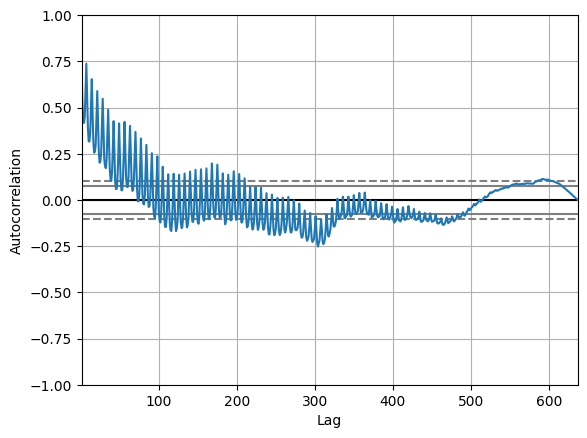

In [34]:
# Autocorrelation & Seasonality Check
df_claims['ClaimCreatedDT_UTC'] = pd.to_datetime(df_claims['ClaimCreatedDT_UTC'])
daily = df_claims_ts['2024-06-01':'2026-03-01'].resample('D').size()
autocorrelation_plot(daily)
plt.show()

In [31]:
# Correlation heatmap claims
cols_claims = [
    'LeadTimeDays',
    'TourNights',
    'Padult',
    'Pchild',
    'PaxSeats',
    'HotelCost',
    'FlightCost_Fwd',
    'FlightCost_Bck',
    'RevisionAmount_Fwd'
]

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — df_claims Features')
plt.tight_layout()
plt.show()

NameError: name 'corr' is not defined

<Figure size 1000x800 with 0 Axes>

The claims dataset contains **37 674 rows** and **64 columns**, covering
the departure period from **January 2024 to March 2026**. Each row should represent a single tour package claim for the destination **Vietnam**, created by a travel agency on behalf of an end customer.

Spearman correlation analysis reveals several multicollinear features in df_claims. PaxSeats shows high correlation with Padult (0.74) and Pchild (0.66), making the individual passenger counts redundant. RevisionAmount_Fwd correlates strongly with FlightCost_Fwd (0.81). These pairs will be addressed during feature selection to avoid multicollinearity in the model.

The dataset includes the following key information:
- **Booking behaviour:** claim creation date, departure date, lead time
  in days, tour duration, number of nights
- **Passengers:** number of adults, children, and infants per booking
- **Product details:** hotel name, star rating, meal plan, room type,
  accommodation type, hotel region
- **Pricing:** hotel cost, flight cost (forward and return),
  total hotel cost, revision amounts
- **Flight information:** departure and arrival cities, flight class,
  airline partner, freight IDs

**Data Quality:**
- Missing values: 145
- Duplicate ClaimIDs: 0
- Duplicate rows: 0
- Currency: all USD
- No cancellations, this dataset contains only active bookings.

**Data Concerns:**
- 29 missing values in hotel-related fields all belong to the all belong to Dynamic Package and Beach Tours. Will be excluded from model training because the tour package should include hotel + flight.
- 27 zero lead time bookings claims created on the same day as departure. Will be excluded from model training.
- 9 Unpaid claims will be excluded from this model training.

# 3.2. Flights Data Overview

1. General Overview
2. Data Types
3. Duplicate Check
4. Basic Statistics
5. Airlines & Routes Distribution
6. Load Factor

In [ ]:
# 1. General Overview
print(f'Rows: {df_flights.shape[0]:,}')
print(f'Columns: {df_flights.shape[1]}')
print(f'BlockDate: {df_flights["BlockDate"].min()} - {df_flights["BlockDate"].max()}')
print(f'Missing: {df_flights.isnull().sum().sum()}')

In [ ]:
# 2. Data types
df_flights.dtypes

In [ ]:
# 3. Duplicate Check
print(f'Duplicate FreightIDs: {df_flights["FreightID"].duplicated().sum()}')
print(f'Duplicate rows:       {df_flights.duplicated().sum()}')

In [ ]:
# 4. Basic statistics
print(df_flights[['Seats_net', 'Sold_net', 'Empty',
                   'TotalDaysInSale']].describe().round(2))

In [ ]:
#5. Airlines & Routes Distribution
print(df_flights['AirlineName'].value_counts())

In [ ]:
df_flights['Route'] = df_flights['CityFrom'] + ' -> ' + df_flights['CityTo']
print(df_flights['Route'].value_counts())

In [ ]:
print(df_flights['Country'].value_counts())

In [ ]:
# 6. Load Factor - the percentage of available seats that were sold on a flight. It is the target variable of this study
df_flights['LoadFactor'] = (df_flights['Sold_net'] / df_flights['Seats_net'] * 100).round(2)
print(df_flights['LoadFactor'].describe().round(2))

In [ ]:
print(f'LF > 100% (sanity check): {(df_flights["LoadFactor"] > 100).sum()}')
print(f'LF = 100% (fully sold):  {(df_flights["LoadFactor"] == 100).sum()}')
print(f'LF = 0%   (empty):       {(df_flights["LoadFactor"] == 0).sum()}')
print(f'LF < 50%  (low demand):  {(df_flights["LoadFactor"] < 50).sum()}')
print(f'LF 50-80% (normal):      {((df_flights["LoadFactor"] >= 50) & (df_flights["LoadFactor"] < 80)).sum()}')
print(f'LF > 80%  (high demand): {(df_flights["LoadFactor"] >= 80).sum()}')

In [ ]:
print(df_flights.groupby('AirlineName')['LoadFactor'].mean().round(2).sort_values(ascending=False))

In [ ]:
# Check negative TotalDaysInSale
print(df_flights[df_flights['TotalDaysInSale'] < 0]['TotalDaysInSale'].describe())
print(f"\nCount: {(df_flights['TotalDaysInSale'] < 0).sum()}")

In [ ]:
df_flights[df_flights['TotalDaysInSale'] < 0]

In [ ]:
print(df_flights['IsReturn'].value_counts())

In [ ]:
# Correlation heatmap
cols = ['LoadFactor', 'TotalDaysInSale',
        'days_to_first_reserve', 'Seats_net', 'HasStopSale']

corr = df_flights[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

The flight load history dataset contains **4 015 rows** and **32 columns**,
covering charter flight blocks operated on Kazakhstan -> Vietnam and Vietnam -> Kazakhstan routes, from **January 2024 to March 2026**.

Each row represents a single charter flight block assigned to the
operator, containing capacity and sales information at the time of
the data snapshot.

The dataset includes the following key information:
- **Flight details:** flight name, block date, airline partner,
  departure and arrival cities, flight class
- **Capacity:** gross seats available, net seats available
- **Demand signals:** seats sold (gross and net), empty seats,
  total days in sale
- **Operational flags:** hard block indicator, stop sale flag,
  on-request flag, release days

**Data Quality:**
- Missing values: **None detected**
- Duplicate rows: **0**
- Duplicate FreightIDs: **3,930** expected, as the same flight in different days

**Routes Distribution:**
- Main routes: Almaty - Cam Ranh, Almaty - Phu Quoc,
  Astana - Cam Ranh, Astana - Phu Quoc
- Countries covered: Vietnam, Kazakhstan, Uzbekistan

**TOP 3 Airlines:**
- SCAT
- Air Astana
- VietJet Air

**Data Concerns:**

- Seats_net / Sold_net used instead of gross_net values reflect only the Kazakhstan office allocation, which is the scope of this study.
- 152 Uzbekistan routes excluded, only Kazakhstan -> Vietnam direction is relevant for the model.
- LF = 0% (488 flights) flagged likely future flights or stopped sales, will be reviewed in EDA.
- LF = 100% (2,665 flights) the majority of flights are fully sold out, will be reviewed in EDA.
- 1 flight with TotalDaysInSale = -167 (Cam Ranh -> Tashkent), data error, excluded together with Uzbekistan routes.

TotalDaysInSale and days_to_first_reserve show perfect correlation (1.00), one will be excluded from the model to avoid multicollinearity. Flight-level features show weak correlation with LoadFactor (max 0.17), confirming that the main predictive signal will come from cumulative booking data reconstructed from claims.

**IMPORTANT!** No as-of (point-in-time) snapshots available, cumulative booking state at each window (D-90, D-60, D-30, D-7) will be reconstructed from claims data in the preprocessing step.

 # 4. Exploratory Data Analysis (EDA)

1. EDA for df_claims
2. EDA for df_flights

### 1) EDA for df_claims

1. Lead Time Distribution
2. Booking Pace Over Time
3. Seasonality Patterns
4. Price Distribution
5. PaxSeats
6. Top hotels / regions

#### 1. Lead Time Distribution

Lead time is the number of days between the booking creation
date and the departure date.

In [ ]:
# Figure 1: Lead Time Distribution

# Step 1: Filter out LeadTimeDays = 0
claims_plt = df_claims['LeadTimeDays']

# Step 2: Create the histogram
plt.figure(figsize=(12, 5))
plt.hist(claims_plt, bins=50, color='steelblue')

# Step 3: Add vertical lines for each booking window
plt.axvline(x=7,  color='red',    linestyle='--', label='D-7')
plt.axvline(x=30, color='orange', linestyle='--', label='D-30')
plt.axvline(x=60, color='green',  linestyle='--', label='D-60')
plt.axvline(x=90, color='purple', linestyle='--', label='D-90')
plt.axvline(x=120, color='pink', linestyle='--', label='D-120')
plt.axvline(x=150, color='black', linestyle='--', label='D-150')

# Step 4: Add labels and title
plt.title('Lead Time Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Days Before Departure')
plt.ylabel('Number of Bookings')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# % of bookings days before departure
for d in [7, 30, 60, 90, 120]:
    pct = (claims_plt >= d).sum() / len(claims_plt) * 100
    print(f"Booked by D-{d}: {pct:.1f}%")

#### 2. Booking Pace Over Time

Booking pace shows how many tour packages were booked per month.

In [ ]:
# Convert to datetime
df_claims['ClaimCreatedDT_UTC'] = pd.to_datetime(df_claims['ClaimCreatedDT_UTC'])
df_claims['DepartureDT'] = pd.to_datetime(df_claims['DepartureDT'])

In [ ]:
# Figure 2: Monthly Booking Volume

# Step 1: Extract the month from the booking date
df_claims['BookingMonth'] = df_claims['ClaimCreatedDT_UTC'].dt.to_period('M')

# Step 2: Count how many bookings happened in each month
monthly_active = df_claims.groupby('BookingMonth').size().reset_index(name='Bookings')

# Step 3: Draw the bar chart per month
plt.figure(figsize=(12, 5))
plt.bar(monthly_active['BookingMonth'].astype(str), monthly_active['Bookings'],
        color='steelblue', edgecolor='white')
plt.title('Monthly Booking Volume',
          fontsize=12, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

In [ ]:
df_claims_ts = df_claims.set_index('ClaimCreatedDT_UTC').sort_index()

# Count bookings per day
daily = df_claims_ts['2024-06-01':'2026-03-01'].resample('D').size()
daily.plot(grid=True, figsize=(8, 3.5))
plt.show()

### 3. Seasonality Patterns

Seasonality analysis examines which months have the highest booking demand for Vietnam routes.

In [ ]:
# Figure 3: Departure Month Distribution

# Step 1: Extract departure month
df_claims['DepartureMonth'] = df_claims['DepartureDT'].dt.month

# Step 2: Month names for readable format
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec']

# Step 3: Count how many bookings happened in each month
monthly_dep = df_claims.groupby('DepartureMonth').size()

# Step 4: Plot
plt.figure(figsize=(12, 5))
plt.bar(month_names, monthly_dep.values,
    color='steelblue', edgecolor='white')
plt.title('Departure Month Distribution',
      fontsize=12, fontweight='bold')
plt.xlabel('Departure Month')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

### 4. Price Distribution

Price distribution analysis examines the spread of flight and hotel
costs across all bookings. This helps identify outliers, understand
pricing segments and prepare the Price Ratio feature for modelling.

In [ ]:
# Figure 4: Flight Cost Distribution

# Step 1: Calculate key percentiles
p25 = df_claims['FlightCost_Fwd'].quantile(0.25)
p50 = df_claims['FlightCost_Fwd'].quantile(0.50)
p75 = df_claims['FlightCost_Fwd'].quantile(0.75)
p99 = df_claims['FlightCost_Fwd'].quantile(0.99)

# Step 2: Plot histogram
plt.figure(figsize=(12, 5))
plt.hist(df_claims['FlightCost_Fwd'].clip(upper=p99),
        bins=50,
        color='steelblue',
        edgecolor='white',
        alpha=0.85)

# Step 3: Add vertical lines for each percentile
plt.axvline(x=p25, color='blue',   linestyle='--',
          linewidth=1.5, label=f'P25 = ${p25:.0f}')
plt.axvline(x=p50, color='green',  linestyle='--',
          linewidth=1.5, label=f'P50 = ${p50:.0f}')
plt.axvline(x=p75, color='orange', linestyle='--',
          linewidth=1.5, label=f'P75 = ${p75:.0f}')
plt.axvline(x=p99, color='red',    linestyle='--',
          linewidth=1.5, label=f'P99 = ${p99:.0f}')

# Step 4: Add labels and title
plt.title('Forward Flight Cost Distribution with Percentiles',
        fontsize=13, fontweight='bold')
plt.xlabel('Flight Cost (USD)')
plt.ylabel('Number of Bookings')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Count anomalies
print(f'Negative flight costs: {(df_claims["FlightCost_Fwd"] < 0).sum()}')
print(f'Zero flight costs:     {(df_claims["FlightCost_Fwd"] == 0).sum()}')

In [ ]:
# Figure 4: Hotel Cost Distribution

# Step 1: Plot histogram with ALL hotel cost values
plt.figure(figsize=(12, 5))
plt.hist(df_claims['HotelCost'], bins=100,
    color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Hotel Cost Distribution',
    fontsize=13, fontweight='bold')
plt.xlabel('Hotel Cost (USD)')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

In [ ]:
# HotelCost statistics
print(df_claims['HotelCost'].describe().round(2))

In [ ]:
# Zero and negative values
print('\nZero hotel cost:',
(df_claims['HotelCost'] == 0).sum())
print('Negative hotel cost:',
(df_claims['HotelCost'] < 0).sum())

### 5. PaxSeats
Passenger Group Size per Booking

In [ ]:
print(df_claims['PaxSeats'].describe().round(2))

### 6. Top hotels / regions

In [ ]:
# Top 10 hotels by booking volume
print(df_claims['HotelName'].value_counts().head(10))

In [ ]:
# Top regions
print(df_claims['HotelRegion'].value_counts())

# EDA for df_claims summary

1. **Lead Time Distribution**

Most bookings are made close to departure, only 15% of demand is visible at D-90. This confirms a late-booking market. However, for pricing decisions, the early window D-90 is most valuable to react and adjust prices effectively.

2. **Booking Pace Over Time**

Booking volume grew significantly from mid-2024 as this was a newly launched market. Therefore, model training will use data from 01.07.2024 to 28.02.2026 to capture real and stable demand patterns. From late 2025, monthly booking volume stabilised at around 1,700–2,000 bookings per month.

3. **Seasonality Patterns**

Peak departure months are January and February (5,300 bookings each), followed by December and November. The lowest demand is in September and April–May. This reflects a clear winter seasonality.

4. **Group Size Distribution**

PaxSeats median is 2, max is 11.

5. **Price Distribution**

Forward flight cost median is 749, with 25% paying over 1,097. Hotel cost median is 673, but the mean is 991 due to expensive outliers (max 16,063). 14 zero hotel cost bookings belong to Info Tours for agents and will be excluded.

6. **Top Hotels and Regions**

Phu Quoc (47%) and Nha Trang (44%) dominate demand. Da Nang represents only 8%. Wyndham Grand Phu Quoc is the most booked hotel with 2,982 bookings. HotelRegion will be an important feature for the model.

### 2) EDA for df_flights

1. Load Factor Distribution
2. Operational Flags
3. Sales Window Analysis
4. First reservation to departure
5. Flight Name Quality Check
6. Flight Cleaning
7. City Analysis
8. Flight Direction Analysis

###1. Load Factor Distribution
Load Factor is the percentage of available seats that were sold on a flight. It is the target variable of this study

In [ ]:
# Plot Load Factor distribution
plt.figure(figsize=(12, 5))
plt.hist(df_flights['LoadFactor'], bins=50,
         color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Load Factor Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Load Factor (%)')
plt.ylabel('Number of Flights')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Kernel Density Estimation for LoadFactor
sns.kdeplot(df_flights['LoadFactor'], fill=True, color='steelblue')
plt.title('LoadFactor KDE')
plt.xlabel('Load Factor (%)')
plt.show()

###2. Operational Flags

In [ ]:
print(df_flights['HasStopSale'].value_counts())
print('-------------------')
print(df_flights['IsOnRequest'].value_counts())
print('-------------------')
print(df_flights['hard_block'].value_counts())
print('-------------------')
print(df_flights['ClassAlias'].value_counts())

### 3. Sales Window Analysis

In [ ]:
print(df_flights['TotalDaysInSale'].describe().round(1))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
df_flights['TotalDaysInSale'].dropna().plot(kind='hist', bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Total Days In Sale Distribution')
ax.set_xlabel('Days in Sale')
ax.set_ylabel('Number of flights')
plt.tight_layout()
plt.show()

### 4. First reservation to departure

In [ ]:
# days from first reservation to departure
df_flights['first_reserve_utc'] = pd.to_datetime(df_flights['first_reserve_utc'])
df_flights['BlockDate'] = pd.to_datetime(df_flights['BlockDate'])

df_flights['days_to_first_reserve'] = (df_flights['BlockDate'] - df_flights['first_reserve_utc']).dt.days
print(df_flights['days_to_first_reserve'].describe().round(1))

### 5. Flight Name Quality Check

In [ ]:
print(df_flights['FlightName'].unique())

In [ ]:
long_names = df_flights[df_flights['FlightName'].str.len() > 10]['FlightName'].unique()
print(long_names)

In [ ]:
test_flights = df_flights[df_flights['FlightName'].str.lower().str.contains('test|fake', na=False)]['FlightName'].unique()
print(test_flights)

###6. Flight Cleaning

In [ ]:
exclude_pattern = r'test|fake|íåàêò'

In [ ]:
df_clean = df_flights[
    ~df_flights['FlightName'].str.contains(exclude_pattern, case=False, na=False) &
    (df_flights['TotalDaysInSale'] > 0) &
    (df_flights['CityFrom'] != 'Tashkent')
].copy()

In [ ]:
# FreightID + BlockDate = unique flight on a specific date
print(f'Unique FreightIDs: {df_clean["FreightID"].nunique()}')
print(f'Unique FreightID + BlockDate: {df_clean.groupby(["FreightID", "BlockDate"]).ngroups}')

In [ ]:
print('-------- FreightID + BlockDate -----------')
print(f'Before:    {df_flights.groupby(["FreightID", "BlockDate"]).ngroups} flights')
print(f'After:    {df_clean.groupby(["FreightID", "BlockDate"]).ngroups} flights')

print('-------- FreightID -----------')
print(f'Before: {df_flights.FreightID.nunique()} flights')
print(f'After: {df_clean.FreightID.nunique()} flights')

### 7. City Analysis

In [ ]:
print(df_clean[['CityFrom', 'Country', 'BusinessEntity']].drop_duplicates().sort_values('CityFrom'))

In [ ]:
print(df_clean.groupby('CityFrom')['FreightID'].nunique().sort_values(ascending=False))

df_last_clean = (
    df_clean
    .sort_values('snapshot_ts_utc')
    .groupby('FreightID', as_index=False)
    .last()
)

### 8. Flight Direction Analysis

In [ ]:
KZ_CITIES = ['Almaty', 'Astana', 'Shymkent', 'Kostanay', 'Aktobe', 'Ural`sk',
             'Karaganda', 'Pavlodar', 'Semey', 'Oskemen', 'Atyrau', 'Aktau',
             'Kyzylorda', 'Taraz', 'Petropavl', 'Rudny']

In [ ]:
# KZ -> Vietnam
fwd = df_clean[
    (df_clean['IsReturn'] == 0) &
    (df_clean['CityFrom'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'CityFrom', 'CityTo']].drop_duplicates()

# Vietnam -> KZ
bck = df_clean[
    (df_clean['IsReturn'] == 1) &
    (df_clean['CityTo'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'CityFrom', 'CityTo']].drop_duplicates()

print(f'Flights Forward: {fwd.FreightID.nunique()}')
print(f'Flights Back: {bck.FreightID.nunique()}')
print(f'BlockDate Forward Range: {fwd.BlockDate.min()} - {fwd.BlockDate.max()}')
print(f'BlockDate Back Range: {bck.BlockDate.min()} - {bck.BlockDate.max()}')


In [ ]:
# Grain Forward (FreightID × BlockDate)
grain_fwd = df_clean[
    (df_clean['IsReturn'] == 0) &
    (df_clean['CityFrom'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'FlightName',
   'CityFrom', 'CityTo', 'AirlineName',
   'Seats_net', 'Sold_net', 'LoadFactor',
   'HasStopSale', 'TotalDaysInSale',
   'days_to_first_reserve', 'releasedays',
   'first_reserve_utc']].drop_duplicates()

print(f'Unique FreightID × BlockDate (FRW): {len(grain_fwd)}')
print(f'Unique FreightID (FRW): {grain_fwd.FreightID.nunique()}')
print(grain_fwd.groupby(['FreightID','FlightName'])['BlockDate'].count().sort_values(ascending=False).head(10))

In [ ]:
check = grain_fwd.groupby(['FreightID', 'BlockDate'])['AirlineName'].nunique()
print(f'Max Airline for FreightID × BlockDate: {check.max()}')
print(f'Cases > 1: {(check > 1).sum()}')

In [ ]:
# Grain Back (FreightID × BlockDate)
grain_bck = df_clean[
    (df_clean['IsReturn'] == 1) &
    (df_clean['CityTo'].isin(KZ_CITIES))
][['FreightID', 'BlockDate', 'FlightName',
   'CityFrom', 'CityTo', 'AirlineName',
   'Seats_net', 'Sold_net', 'LoadFactor',
   'HasStopSale', 'TotalDaysInSale',
   'days_to_first_reserve', 'releasedays',
   'first_reserve_utc']].drop_duplicates()

print(f'Unique FreightID × BlockDate (BACK): {len(grain_bck)}')
print(f'Unique FreightID (BACK): {grain_bck.FreightID.nunique()}')
print(grain_bck.groupby(['FreightID','FlightName'])['BlockDate'].count().sort_values(ascending=False).head(10))

In [ ]:
check = grain_bck.groupby(['FreightID', 'BlockDate'])['AirlineName'].nunique()
print(f'Max Airline for FreightID × BlockDate: {check.max()}')
print(f'Cases > 1: {(check > 1).sum()}')

In [ ]:
print('=== Forward ===')
print(grain_fwd['LoadFactor'].describe().round(3))
print(f'\n=== Back ===')
print(grain_bck['LoadFactor'].describe().round(3))

# EDA summary: df_flights

**1. Load Factor Distribution**

The target variable LoadFactor shows a bimodal distribution with peaks at 0% and 100%, confirming that the dataset represents final flight states rather than in-progress booking states. Flights with LF=0% (future or unsold flights) will be excluded from model training. The remaining distribution is left-skewed, with the majority of flights fully sold.Cumulative booking state will be reconstructed from claims data in the preprocessing step.

**2. Operational Flags**

HasStopSale: 503 flights (12.5%) have stop sale activated. Will be used as a feature.
IsOnRequest, hard_block, ClassAlias: no variation and will be excluded from model.

**3. Sales Window Analysis**

Flights are on sale for a median of 156 days (roughly 5 months). Distribution is approximately normal between 100–250 days. TotalDaysInSale will be considered as a feature.

**4. First Reservation to Departure**

Flights open for sale a median 155 days before departure.

**5. Flight Name Quality Check**

test flights were detected (Test, VSV4444test, VSV10000TEST, VSV9999TEST) and flights with corrupted names containing Cyrillic encoding errors — all excluded from analysis.

**6. Flight Cleaning**

After removing test flights, Tashkent routes and negative TotalDaysInSale: 74 unique FreightIDs, 3,818 unique FreightID × BlockDate combinations remain.

**7. City Analysis**

All flights belong to KZ business entity. Main departure cities: Phu Quoc (24), Almaty (16), Cam Ranh (13), Astana (11). Uzbekistan routes excluded.

**8. Flight Direction Analysis**

Forward (KZ -> VN): 31 unique flights, 1,835 departure dates
Return (VN -> KZ): 39 unique flights, 1,831 departure dates
Each FreightID × BlockDate has exactly 1 airline, no conflicts detected